In [4]:
#import libraries
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from gll import gll
from lagrange2 import lagrange2

# Prettier plots.
plt.style.use('ggplot')

Solution of the analytical integral: 0.666667
Solution of the numerical integral: 0.666668


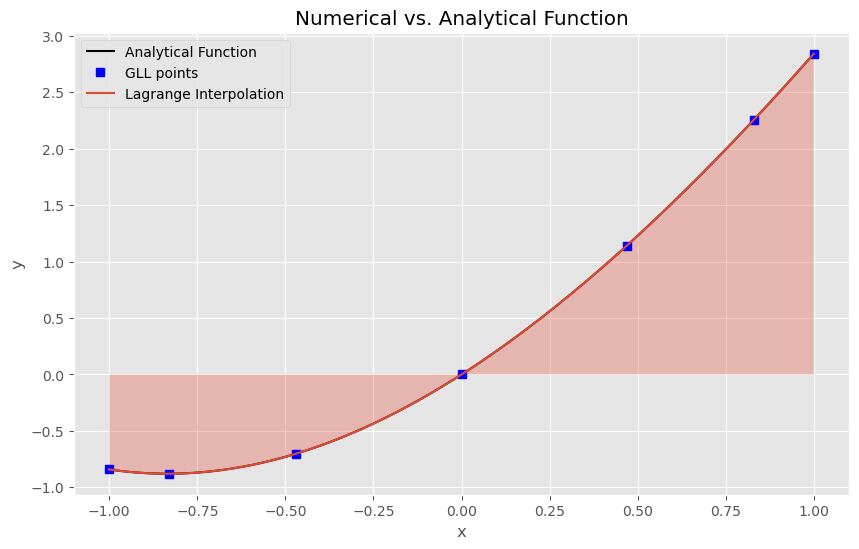

In [5]:
# Exercise for Gauss integration
n = 1000 
x = np.linspace(-1, 1, n)

# MODIFY f and intf to test different functions!
#f = np.sin(x * np.pi) 
f = x + x * x + np.sin(x)

# Analytical value of the DEFINITE integral from -1 to 1
#intf = 1.0 / np.pi * (-np.cos(1.0 * np.pi) + np.cos(-1.0 * np.pi))
intf = 2./3.

# Choose order
N = 6

# Get integration points and weights from the gll routine
xi, w = gll(N)

# Initialize function at points xi
fi = np.interp(xi, x, f)

################################################
# Evaluate integral
intfn = 0
for i in range(len(w)):
    intfn = intfn + w[i] * fi[i]
################################################    


# Calculate Lagrange Interpolant for plotting purposes.
lp = np.zeros((N + 1, len(x)))
for i in range(0, len(x)):
    for j in range(-1, N):
        lp[j + 1, i] = lagrange2(N, j, x[i], xi)
s = np.zeros_like(x)
for j in range(0, N + 1):   
    s = s + lp[j, :] * fi[j]
    
print('Solution of the analytical integral: %g' % intf)
print('Solution of the numerical integral: %g' % intfn)

# -------------------
# Plot results
plt.figure(figsize=(10, 6))
plt.plot(x, f, 'k-', label='Analytical Function')

plt.plot(xi, fi, 'bs', label='GLL points')
plt.plot(x, s, label='Lagrange Interpolation')
plt.fill_between(x, s, np.zeros_like(x), alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Numerical vs. Analytical Function')

plt.legend()
plt.show()